In [ ]:
import numpy as np

# SEMILLA para reproducibilidad
np.random.seed(42)

# 1000 datos
n = 10000

# LISTA 1: Terreno (m²) - distribución realista
terreno_m2 = np.clip(
    np.random.normal(250, 60, n),  # Media 250, desv 60
    80, 500  # Límites realistas
).astype(int)

# LISTA 2: Precio ($) - RELACIONADO con terreno
precio_base = terreno_m2 * 1500  # 1500$/m² base
precio = np.clip(
    precio_base * (1 + np.random.normal(0, 0.12, n)),  # ±12% ruido
    150000, 900000
).astype(int)


In [19]:
for i in range(10):
    print(f"Fila {i+1:2d}: {terreno_m2[i]:3d}M² -> ${precio[i]:,}")

Fila  1: 279M² -> $488,775
Fila  2: 241M² -> $401,610
Fila  3: 288M² -> $435,091
Fila  4: 341M² -> $471,791
Fila  5: 235M² -> $382,034
Fila  6: 235M² -> $369,144
Fila  7: 344M² -> $571,430
Fila  8: 296M² -> $477,841
Fila  9: 221M² -> $373,251
Fila 10: 282M² -> $395,831


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ========================================
# PASO 1: TUS 1000 DATOS (ya explicados)
# ========================================
np.random.seed(42)
n = 1000

superficies = np.clip(np.random.normal(250, 60, n), 80, 500).astype(int)
precios = np.clip(superficies * 1500 * (1 + np.random.normal(0, 0.12, n)), 150000, 900000).astype(int)

print(f"✅ 1000 datos cargados")
print(f"Superficies: {superficies.min()} - {superficies.max()} m²")
print(f"Precios: ${precios.min():,} - ${precios.max():,}")

# ========================================
# PASO 2: ALGORITMO DEL DOCENTE (adaptado)
# ========================================
# Rangos para buscar (más gruesos por 1000 datos)
rango_a = np.arange(1000, 2001, 50)   # Coeficiente de x (pendiente)
rango_b = np.arange(-50000, 50001, 5000)  # Término independiente

print(f"\n🔍 Buscando en {len(rango_a)} × {len(rango_b)} = {len(rango_a)*len(rango_b)} combinaciones...")

mejor_error = float('inf')
mejor_a = None
mejor_b = None

# ¡BÚSQUEDA EXHAUSTIVA!
for b in rango_b:        # ← b = theta0 (intercepto)
    for a in rango_a:    # ← a = theta1 (pendiente)
        error_acumulado = 0
        
        # Para CADA dato
        for indice, x in enumerate(superficies):
            y_pred = a * x + b              # ← Ecuación línea: y = a*x + b
            error_actual = (y_pred - precios[indice])**2  # ← Error al cuadrado
            error_acumulado += error_actual
        
        # Error promedio (MSE)
        error_acumulado = error_acumulado * (1 / (2 * len(superficies)))
        
        if error_acumulado < mejor_error:
            mejor_error = error_acumulado
            mejor_a = a
            mejor_b = b

print(f"\n🎯 RESULTADO ENCONTRADO!")
print(f"Coeficiente de x (a): {mejor_a}")
print(f"Término independiente (b): {mejor_b}")
print(f"Error final (MSE): {mejor_error:,.0f}")
print(f"Ecuación: precio = {mejor_a} * terreno + {mejor_b}")


✅ 1000 datos cargados
Superficies: 80 - 481 m²
Precios: $150,000 - $872,978

🔍 Buscando en 21 × 21 = 441 combinaciones...

🎯 RESULTADO ENCONTRADO!
Coeficiente de x (a): 1450
Término independiente (b): 15000
Error final (MSE): 1,067,607,983
Ecuación: precio = 1450 * terreno + 15000


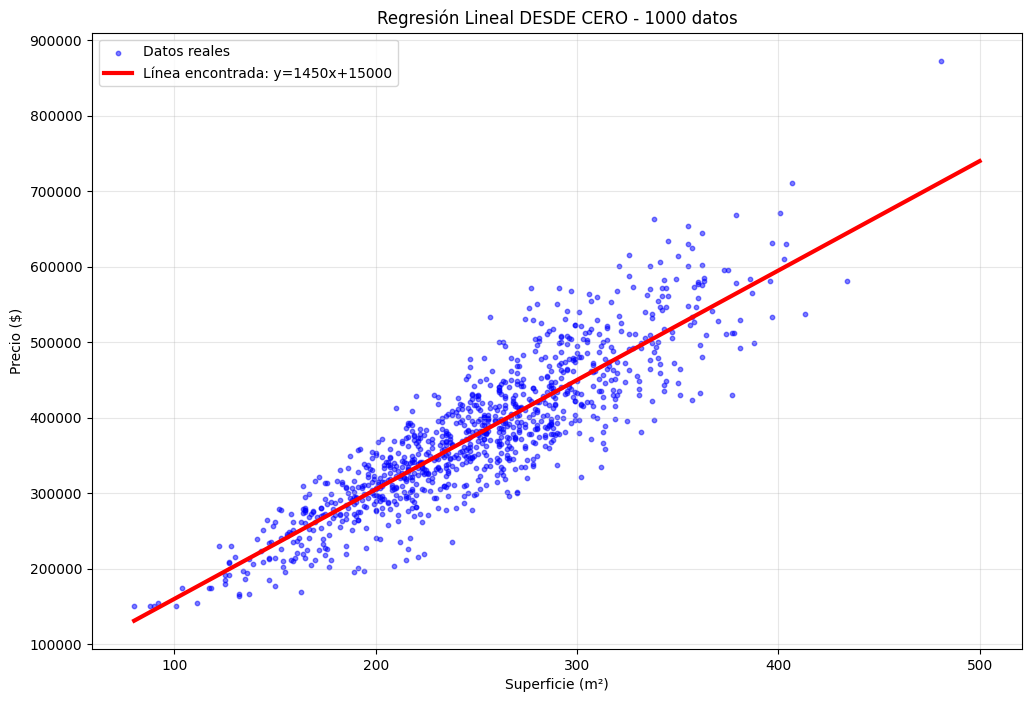


🧮 EJEMPLO: Terreno 300m² → Precio predicho: $450,000


In [21]:
# Gráfico con línea encontrada
plt.figure(figsize=(12, 8))

# Puntos reales (tus 1000 datos)
plt.scatter(superficies, precios, alpha=0.5, s=10, color='blue', label='Datos reales')

# Línea encontrada por el algoritmo
x_linea = np.linspace(80, 500, 100)
y_linea = mejor_a * x_linea + mejor_b
plt.plot(x_linea, y_linea, color='red', linewidth=3, label=f'Línea encontrada: y={mejor_a}x+{mejor_b}')

plt.xlabel('Superficie (m²)')
plt.ylabel('Precio ($)')
plt.title('Regresión Lineal DESDE CERO - 1000 datos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Predicción ejemplo
terreno_ejemplo = 300
precio_predicho = mejor_a * terreno_ejemplo + mejor_b
print(f"\n🧮 EJEMPLO: Terreno 300m² → Precio predicho: ${precio_predicho:,.0f}")


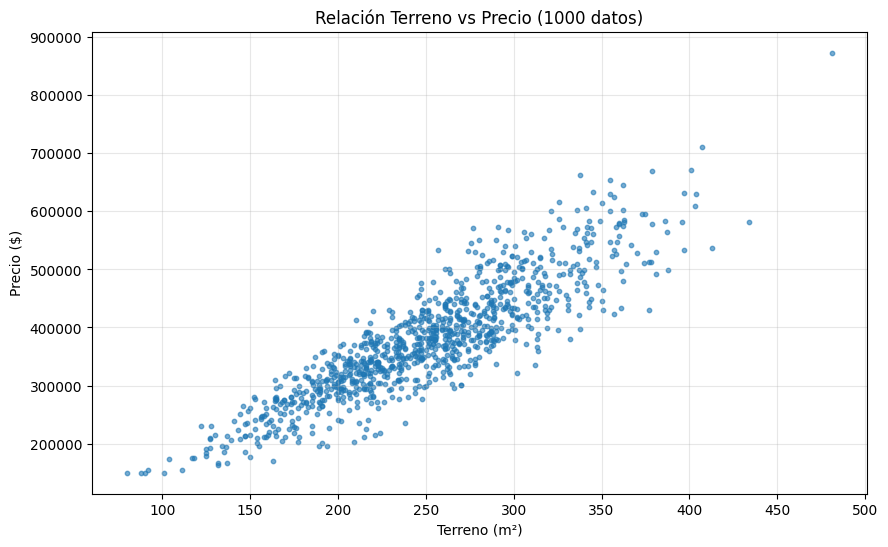

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(terreno_m2, precio, alpha=0.6, s=10)
plt.xlabel('Terreno (m²)')
plt.ylabel('Precio ($)')
plt.title('Relación Terreno vs Precio (1000 datos)')
plt.grid(True, alpha=0.3)
plt.show()
